# Figure 4A/B/G: Jiang24 ablation analyses

Reproduces the Jiang24 architecture, train-size, and train-test distance ablation panels.


In [1]:
# Set to True to write image files to figures/main/output/.
SAVE_FIGURES = False

## Architecture and train-size ablations


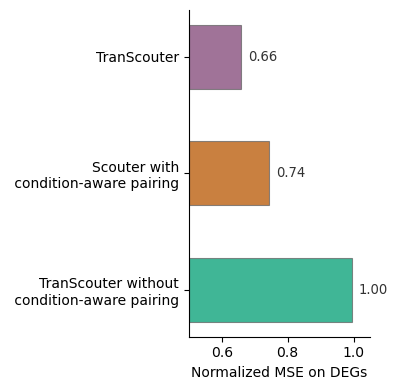

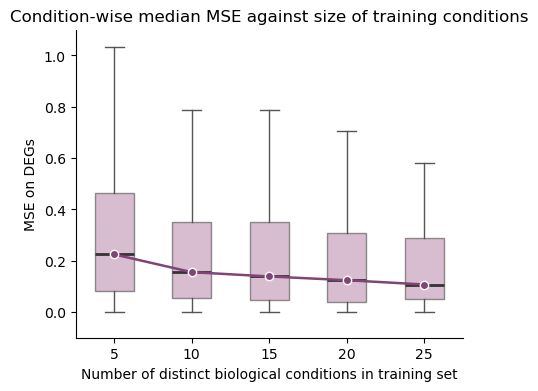

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
import pandas as pd
from pathlib import Path
ROOT = Path.cwd().resolve()
while not ((ROOT / "transcouter").is_dir() and (ROOT / "code").is_dir() and (ROOT / "figures").is_dir()) and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if not ((ROOT / "transcouter").is_dir() and (ROOT / "code").is_dir() and (ROOT / "figures").is_dir()):
    raise RuntimeError("Run this notebook from inside the TranScouter repository")
os.chdir(ROOT)
Path("figures/main/output").mkdir(parents=True, exist_ok=True)
Path("figures/supplement/output").mkdir(parents=True, exist_ok=True)

# fmt: off
check_cols = ["NormMSE_degs", "DirectProp_degs"]

############################ TranScouter ############################
jiang_transcouter = pd.read_csv("results/transcouter/jiang/metrics.csv", index_col=0)
jiang_transcouter["DirectProp_all"] = jiang_transcouter["SameDirect_all"] / (jiang_transcouter["SameDirect_all"] + jiang_transcouter["DiffDirect_all"])
jiang_transcouter["DirectProp_degs"] = jiang_transcouter["SameDirect_degs"] / (jiang_transcouter["SameDirect_degs"] + jiang_transcouter["DiffDirect_degs"])

seen0 = (~jiang_transcouter.cov_seen) & (~jiang_transcouter.pert_seen)
seen_cov = jiang_transcouter.cov_seen & (~jiang_transcouter.pert_seen)
seen_pert = (~jiang_transcouter.cov_seen) & jiang_transcouter.pert_seen
jiang_transcouter[seen0][check_cols].median()

############################ vanilla Scouter structure ############################
jiang_vanilla = pd.read_csv("results/ablation/architecture/Jiang.csv", index_col=0)
jiang_vanilla["DirectProp_all"] = jiang_vanilla["SameDirect_all"] / (jiang_vanilla["SameDirect_all"] + jiang_vanilla["DiffDirect_all"])
jiang_vanilla["DirectProp_degs"] = jiang_vanilla["SameDirect_degs"] / (jiang_vanilla["SameDirect_degs"] + jiang_vanilla["DiffDirect_degs"])

seen0 = (~jiang_vanilla.cov_seen) & (~jiang_vanilla.pert_seen)
seen_cov = jiang_vanilla.cov_seen & (~jiang_vanilla.pert_seen)
seen_pert = (~jiang_vanilla.cov_seen) & jiang_vanilla.pert_seen
jiang_vanilla[seen0][check_cols].median()


############################ Random Pairing ############################
jiang_randompair = pd.read_csv("results/ablation/random_pairing/Jiang.csv", index_col=0)
jiang_randompair["DirectProp_all"] = jiang_randompair["SameDirect_all"] / (jiang_randompair["SameDirect_all"] + jiang_randompair["DiffDirect_all"])
jiang_randompair["DirectProp_degs"] = jiang_randompair["SameDirect_degs"] / (jiang_randompair["SameDirect_degs"] + jiang_randompair["DiffDirect_degs"])

seen0 = (~jiang_randompair.cov_seen) & (~jiang_randompair.pert_seen)
seen_cov = jiang_randompair.cov_seen & (~jiang_randompair.pert_seen)
seen_pert = (~jiang_randompair.cov_seen) & jiang_randompair.pert_seen
jiang_randompair[seen0][check_cols].median()


############################ Structure Ablation Boxplot ############################
structure_dfs = {
    "TranScouter": jiang_transcouter,
    "Scouter with\n condition-aware pairing": jiang_vanilla,
    "TranScouter without\n condition-aware pairing": jiang_randompair,
}
colors = ["#814476", "#B85500", "#009E73"]

median_normmse = []
for df in structure_dfs.values():
    seen0 = (~df.cov_seen) & (~df.pert_seen)
    median_normmse.append(df.loc[seen0, "NormMSE_degs"].median())

plt.figure(figsize=(4, 4))
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

x_min = 0.5
bars = plt.barh(list(structure_dfs.keys()), [v - x_min for v in median_normmse], left=x_min,
                color=colors, alpha=0.75, edgecolor="0.4", linewidth=0.8, height=0.55)

for bar, val in zip(bars, median_normmse):
    ax.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", fontsize=9.5, color="#333333")

plt.xlabel("Normalized MSE on DEGs")
plt.xlim(x_min, 1.05)
plt.gca().invert_yaxis()
plt.tight_layout()
if globals().get("SAVE_FIGURES", False):
    plt.savefig("figures/main/output/architecture.png", bbox_inches="tight", dpi=300)
plt.show()


############################ Train Size Ablation ############################
condition_mse_by_size = []
median_mse = []
size_ls = [5, 10, 15, 20, 25]
for size in size_ls:
    metric_size =pd.read_csv(f"results/ablation/trainsize/Analysis_{size}.csv", index_col=0)
    # condition_mse = metric_size.groupby('condition')['MSE_TranScouter'].median()
    condition_mse = metric_size["MSE_TranScouter"]
    condition_mse_by_size.append(condition_mse)
    median_mse.append(condition_mse.median())

plt.figure(figsize=(5, 4))
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

bp = plt.boxplot(condition_mse_by_size, tick_labels=size_ls, showfliers=False,
                 patch_artist=True,
                 medianprops={'linewidth': 2, 'color': '#333333'},
                 whiskerprops={'color': '#555555'},
                 capprops={'color': '#555555'},
                 boxprops={'edgecolor': '#555555'})

for patch in bp['boxes']:
    patch.set_facecolor('#C49AB8')
    patch.set_alpha(0.65)

plt.plot(range(1, len(size_ls) + 1), median_mse, marker='o', markersize=6,
         linestyle='-', color='#814476', markerfacecolor='#814476',
         markeredgecolor='white', linewidth=1.8, zorder=5)
plt.xlabel('Number of distinct biological conditions in training set')
plt.ylabel('MSE on DEGs')
plt.ylim(-0.1, 1.1)
plt.title('Condition-wise median MSE against size of training conditions')
if globals().get("SAVE_FIGURES", False):
    plt.savefig("figures/main/output/TrainSize.png", bbox_inches="tight", dpi=300)
plt.show()



## Train-test distance analysis


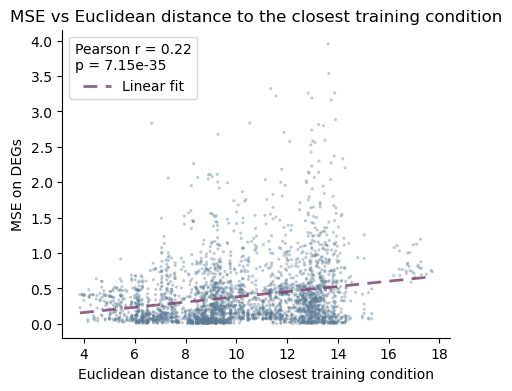

In [3]:
############################ Train-Test Correlation Ablation ############################
import os
import pickle
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch
from scipy.spatial.distance import cdist
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error as mse

ROOT = Path.cwd().resolve()
while not ((ROOT / "transcouter").is_dir() and (ROOT / "code").is_dir() and (ROOT / "figures").is_dir()) and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if not ((ROOT / "transcouter").is_dir() and (ROOT / "code").is_dir() and (ROOT / "figures").is_dir()):
    raise RuntimeError("Run this notebook from inside the TranScouter repository")
os.chdir(ROOT)

sys.path.insert(0, str(ROOT / "code" / "train" / "ablation"))
from network import TranScouterModel

ADATA_PATH = ROOT / "data" / "jiang" / "processed" / "aggregate_sum_hvg.h5ad"
EMBD_PATH = ROOT / "data" / "embeddings" / "GenePT_V1.pickle"
TOP_DEGS_NAMES_PATH = ROOT / "data" / "jiang" / "processed" / "top_degs_names.pkl"
TOP_DEGS_IDX_PATH = ROOT / "data" / "jiang" / "processed" / "top_degs_idx.pkl"
SPLIT_PATH = ROOT / "data" / "jiang" / "splits" / "split_dict_10Fold.pkl"
RESULT_DIR = ROOT / "results" / "ablation" / "train_test_distance"
FIGURE_DIR = ROOT / "figures" / "main" / "output"


def set_seeds(seed=24):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def cond_unseen(cond, test_cov, masked_perts):
    cov_unseen = cond.split("_")[0] in test_cov
    pert_unseen = cond.split("_")[1] in masked_perts
    return cov_unseen and pert_unseen


adata = sc.read_h5ad(ADATA_PATH)
adata.obs["cov_pert"] = adata.obs[["covariate", "perturbation"]].agg("_".join, axis=1)

with open(EMBD_PATH, "rb") as f:
    embd = pd.DataFrame(pickle.load(f)).T
    embd.rename(index={"H1-0": "H1F0"}, inplace=True)
    ctrl_row = pd.DataFrame(
        [np.zeros(embd.shape[1])],
        columns=embd.columns,
        index=["control"],
    )
    embd = pd.concat([ctrl_row, embd])
    embd = embd.loc[adata.obs.perturbation.unique()]
    embd_tensor = torch.tensor(embd.values, dtype=torch.float32)

with open(TOP_DEGS_NAMES_PATH, "rb") as f:
    top_degs_names = pickle.load(f)
with open(TOP_DEGS_IDX_PATH, "rb") as f:
    top_degs_idx = pickle.load(f)
with open(RESULT_DIR / "Jiang.pkl", "rb") as f:
    result = pickle.load(f)
with open(SPLIT_PATH, "rb") as f:
    split_dict = pickle.load(f)

hidden_enc_embd = (512, 256)
hidden_enc_ctrl = (2048, 1024)
bottle_dim = 512
hidden_dec = (1024, 2048)
use_batch_norm = True
use_layer_norm = False
dropout_rate = 0.0
use_sampling = False
condition = "control"

metric_all = []
for split in range(len(split_dict)):
    model = TranScouterModel(
        ctrl_dim=adata.n_vars,
        gene_embd=embd_tensor,
        hidden_enc_embd=hidden_enc_embd,
        hidden_enc_ctrl=hidden_enc_ctrl,
        bottle_dim=bottle_dim,
        hidden_dec=hidden_dec,
        use_batch_norm=use_batch_norm,
        use_layer_norm=use_layer_norm,
        dropout_rate=dropout_rate,
        use_sampling=use_sampling,
        condition=condition,
    )
    model_path = RESULT_DIR / f"model_split{split}.pt"
    stat_dict = torch.load(model_path, map_location=torch.device("cpu"), weights_only=True)
    model.load_state_dict(stat_dict)
    model.eval()

    metric = {"MSE": {}, "Euclidean": {}, "Cosine": {}}
    train_conds, test_conds, masked_perts, test_cov = (
        split_dict[split]["train"],
        split_dict[split]["test"],
        split_dict[split]["masked_perts"],
        split_dict[split]["test_cov"],
    )
    unseen_test_conds = [cond for cond in test_conds if cond_unseen(cond, test_cov, masked_perts)]

    transcouter_split = result[f"split_{split}"]["Prediction"]
    transcouter_split = transcouter_split[transcouter_split.cov_pert.isin(unseen_test_conds)]
    true_split = result[f"split_{split}"]["True"]
    true_split = true_split.loc[transcouter_split.index]

    train_ctrls_name = sorted(np.unique([cond.split("_")[0] + "_control" for cond in train_conds]))
    train_ctrls_ad = adata[adata.obs.cov_pert.isin(train_ctrls_name)]
    encoded_train = model.encoder_ctrl(torch.tensor(train_ctrls_ad.X, dtype=torch.float32)).detach().numpy()

    for bcode in transcouter_split.index:
        cell_type, treat, pert, _, sampleid, donor = bcode.split("_")
        cov = cell_type + "+" + treat
        cond = cov + "_" + pert
        degs = top_degs_names[cond]
        ctrl_bcode = "_".join([cell_type, treat, "control", "sample", sampleid, donor])
        if len(degs) > 1:
            transcouter = transcouter_split.drop(columns="cov_pert")[degs].loc[bcode]
            true = true_split.drop(columns="cov_pert")[degs].loc[bcode]
            metric["MSE"][bcode] = mse(true, transcouter)

            encoded_test = model.encoder_ctrl(torch.tensor(adata[ctrl_bcode].X, dtype=torch.float32)).detach().numpy()
            metric["Euclidean"][bcode] = cdist(encoded_train, encoded_test, metric="euclidean").flatten().min()
            metric["Cosine"][bcode] = cdist(encoded_train, encoded_test, metric="cosine").flatten().min()

    metric_split = pd.DataFrame(metric).assign(split=split)
    metric_all.append(metric_split)

metric_all = pd.concat(metric_all)

x, y = metric_all.Euclidean, metric_all.MSE
slope, intercept = np.polyfit(x, y, 1)
pearson_r, pearson_p = pearsonr(x, y)
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = slope * x_fit + intercept

plt.figure(figsize=(5, 4))
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.scatter(x, y, alpha=0.4, s=5, color="#5B7B94", edgecolors="none")
fit_line, = plt.plot(
    x_fit,
    y_fit,
    color="#814476",
    linewidth=2,
    linestyle=(0, (5, 3)),
    label="Linear fit",
    alpha=0.85,
)
plt.xlabel("Euclidean distance to the closest training condition")
plt.ylabel("MSE on DEGs")
plt.title("MSE vs Euclidean distance to the closest training condition")
plt.legend(handles=[fit_line], title=f"Pearson r = {pearson_r:.2f}\np = {pearson_p:.2e}")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
if globals().get("SAVE_FIGURES", False):
    plt.savefig(FIGURE_DIR / "TrainTestCor.png", bbox_inches="tight", dpi=300)
plt.show()